<a href="https://colab.research.google.com/github/jane-kirina/python_for_ds_and_ml_tasks/blob/main/module_2/topic_1/HW_2_1_2_Feature_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

> Імпорт необхідних бібліотек

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns

> Імпорт даних

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
medical_df = pd.read_csv('drive/MyDrive/Colab Notebooks/_DLA_/module_2/data/medical-charges.csv')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Огляд декількох записів з датафрейму
medical_df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


# Завдання 1


**Завдання 1**: Завантажте дані `medical-charges.csv` в пандас датафрейм і виведіть перші 5 записів. Напишіть, як ви можете підійти до вирішення задачі прогнозування колонки `charges` на основі інших колонок виходячи з наявних на даний момент знань (без ML методів, чисто з використанням аналітики). Запишіть 3 або більше ідей, які приходять вам на думку нижче:

In [ ]:
medical_df.head() # head виводить перші 5 записів

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


**Відповідь:** Якщо думати про дані не з точки ML та дата аналітики, то краще думати з точки зору економіки

1. Розбити людей на групи (курець/некурець, вік, BMI) і брати середній charges та дивитися що сильніше впливає на charges
2. Порівняння - дивитись, скільки платять люди з такими ж характеристиками
3. використовувати графіки для візуалізації даних та зробити аналіз

# Завдання 2

**Завдання 2**: Візуалізуйте розподіл медичних зборів (`charges`) у вигляді інтерактивної гістограми plotly з розбиттями за категоріями ознак
1. `sex`
2. `region`

Додайте маржинальний графік у вигляді бокс-плота вгорі по дикретним категоріям ознак.
Скористайтесь прикладом візуалізації з лекції.
Опишіть свої спостереження.

## Charges & sex

In [ ]:
fig = px.histogram(
    medical_df,
    x='charges',
    color='sex',
    marginal='box',
    color_discrete_sequence=['green', 'grey'],
    title='Annual Medical Charges by Sex'
)

fig.update_layout(bargap=0.1)
fig.show()

> **Різниця між чоловіками та жінками невелика**:
> - Медіанні витрати для чоловіків та жінок-курців дуже близькі `~9.3-9.4k`
> - **Обидва мають великі викидів**: невелика частка клієнтів має дуже високі значення `charges`, але більшість спостережень зосереджена в діапазоні низьких та середніх витрат
> - Правий хвіст у чоловіків довший, **що свідчить про наявність інших факторів**, які частіше зустрічаються у чоловіків. Довший хвіст зумовлений наявністю більшої кількості екстремальних значень, а не вищою медіаною витрат
>
> Гістограма показує, що **стать впливає на медичні витрати лише незначно**, бо розподіли `charges` для чоловіків і жінок схожі по формі та медіани
>
> Схожі викиди у обох статть вказує на наявність окремих груп клієнтів з підвищеними медичними витратами, **ймовірно пов’язаними з іншими факторами, як наприклад значенням BMI та курінням**
>
> `sex` має слабкий самостійний predictive effect, тоді як екстремальні значення `charges` формуються за рахунок взаємодії з іншими факторами ризику. Тому краще використовувати `sex` у поєднанні з іншими ознаками, як `bmi`, `smoker` або `age`


## Charges & region

In [ ]:
fig = px.histogram(medical_df,
                   x='charges',
                   marginal='box',
                   color='region',
                   color_discrete_sequence=['#636EFA', '#EF553B', '#00CC96', '#AB63FA'],
                   title='Annual Medical Charges by region')
fig.update_layout(bargap=0.1)
fig.show()

In [ ]:
fig = px.box(medical_df,
             x='region',
             y="charges",
             color='region',
             color_discrete_sequence=['#636EFA', '#EF553B', '#00CC96', '#AB63FA'],
             )

fig.update_layout(
    title="Distribution of Charges by Region",
    xaxis_title="Region",
    yaxis_title="Charges",
    bargap=0.1
)

fig.show()

- Розподіли у всіх регіонах дуже схожі: основна маса значень зосереджена в діапазоні низьких–середніх витрат, з довгим правим хвостом
- *Box-plot* - медіани витрат між регіонами близькі
- `Southeast` та `Northeast` маєть більший розкид і більше екстремальних значень
- У всіх регіонах присутні outliers, що свідчить про наявність окремих клієнтів з дуже високими медичними витратами

**Висновок**: `region` має слабкий самостійний вплив на `charges` і більше працює як другорядний фактор у поєднанні з іншими змінними як `smoker`, `bmi`, `age`)

# Завдання 3

**Завдання 3**: Візуалізуйте з `plotly` розподіл кожного з настуних стовпців відносно того, чи є людина курцем (`smoker`)
- `region`
- `children`

та опишіть коротко свої спостереження.

## Smoker & region

In [ ]:
fig_region = px.histogram(medical_df,
                          x='region',
                          color='smoker',
                          barmode='group',
                          title='Розподіл smoker за region',
                          color_discrete_sequence=['green', 'grey'],
                          labels={
                              'region': 'Регіон',
                              'count': 'Кількість людей',
                              'smoker': 'Курець'
                              }
                          )
fig_region.show()

In [ ]:
fig = px.box(medical_df[medical_df['smoker'] == 'yes'],
             x='region',
             y='charges',
             color='region',
             color_discrete_sequence=['#636EFA', '#EF553B', '#00CC96', '#AB63FA'],
             )

fig.update_layout(
    title='Distribution of Charges by Region and Smoker Status(yes)',
    xaxis_title='Region',
    yaxis_title='Charges',
    bargap=0.1
)

fig.show()


In [ ]:
fig = px.box(medical_df[medical_df['smoker'] == 'no'],
             x='region',
             y='charges',
             color='region',
             color_discrete_sequence=['#636EFA', '#EF553B', '#00CC96', '#AB63FA'],
             )

fig.update_layout(
    title='Distribution of Charges by Region and Smoker Status(no)',
    xaxis_title='Region',
    yaxis_title='Charges',
    bargap=0.1
)

fig.show()

Ми можемо побачити, що куріння впливає більше всього на медичні витрати

> **Для не курців усе достатньо рівномірно для кожного регіону**:
> - схожа медіана, є деякі викиди та більша варіативність у витрат у більшу сторону
> - **Southeast** та **Southwest** мають більш високі викиди
>
> **Для курців можно побачити незначну різницю у регіонах**:
> - Загально для кожного регіону є винятки з високими витратами
> - У **Southeast** платять найбільше, з явним відривом
> - **Northwest** та **Northeast** мають схожі медіани, обидва нижчі, ніж **south** регіони

> Регіональні відмінності існують, але вони не є більш суттєвими, ніж куріння. Ціни є високіми в кожному регіоні





> **Курці мають високі медичні витрати**:
> - діапазон витрат для курців *10k-60k*, де медіана *~29k* для жінок та *~36k* для чоловіков
> - діапазон витрат для некурців *1k-23k*, де медіана *~7k* для жінок та *~8k* для чоловіков
> - Для некурців існують виняткі, які сягають *25k+*, але це трапляється рідко

## Smokers & children

In [ ]:
fig_region = px.histogram(medical_df,
                          x='children',
                          color='smoker',
                          barmode='group',
                          title='Розподіл smoker залежно від кількості дітей',
                          color_discrete_sequence=['green', 'grey'],
                          labels={
                              'region': 'Регіон',
                              'count': 'Кількість людей',
                              'smoker': 'Курець'
                              }
                          )

fig_region.show()


In [ ]:
fig = px.box(medical_df,
             x='children',
             y="charges",
             color='smoker',
             title='Розподіл charges за кількістю дітей та smoker статусом',
             labels={
                  'children': 'Кількість дітей',
                  'charges': 'Медичні витрати',
                  'smoker': 'Курець'
              },
             color_discrete_sequence=['green', 'grey']
             )

fig.show()

Для некурців розподіл по дітях виглядає стабільніше:
- найбільша частка людей має 0 дітей
- некурці присутні у всіх категоріях, але зі збільшенням дітей загальна кількість спостережень зменшується (бо таких людей в датасеті менше)

Для курців видно зменшення кількості зі зростанням дітей:
- найбільше курців також у групі 0 дітей
- у групах 1–3 дітей курці є, але їх відчутно менше, ніж некурців

Загальний висновок:
- із збільшенням кількості дітей частка/кількість курців зменшується, але категорії 4–5 дітей мають дуже мало спостережень, тому коректніше порівнювати 0–3 дітей, де вибірка більша


# Завдання 4

**Завдання 4**: Візуалізуйте звʼязок між стовпцем `charges` та `children` використовуючи графіки-скрипки (`px.violin`). Опишіть свої спостереження.

In [ ]:
fig = px.violin(medical_df,
                x='children',
                y='charges',
                box=True, # без box violin складніше читати
                points="all",
                title='Charges та children',
                labels={
                    'children': 'Кількість дітей',
                    'charges': 'Медичні витрати'
                    },
                color_discrete_sequence=['#BA5A31']
                )
fig.show()

In [ ]:
fig = px.violin(medical_df,
                x='children',
                y='charges',
                color='smoker',
                box=True,
                color_discrete_sequence=['green', 'grey'],
                title='Charges vs Children + smoker',
                labels={'children': 'Кількість дітей', 'charges': 'Медичні витрати', 'smoker': 'Курець'}
                )
fig.show()


- Для більшості значень `children` медіана `charges` не змінюється різко — кількість дітей сама по собі не дає сильного зростання витрат
- У всіх групах `children` є високі витрати, викади, тобто навіть з однаковою кількістю дітей витрати можуть суттєво відрізнятися
- Для `children = 4` та `5` часто спостережень мало, тому форма скрипки може бути «тонкою» й висновки менш стабільні


# Завдання 5

**Завдання 5.** Розглянемо модель для користувачів, які не є курцями (`no_smoker_df`):

$$charges = w \times age + b$$

Спробуйте 3 різні пари параметрів `w` та `b` аби вручну підігнати лінію під дані використовуючи наведені допоміжні функції `estimate_charges` та `try_parameters`. Опишіть спостереження.
Пари параметрів мають бути НЕ такі, як були наведені в лекції.

In [ ]:
non_smoker_df = medical_df[medical_df.smoker == 'no']

In [ ]:
def estimate_charges(age, w, b):
    return w * age + b

In [ ]:
def try_parameters(df, w, b):
    ages = df.age
    target = df.charges

    estimated_charges = estimate_charges(ages, w, b)

    plt.plot(ages, estimated_charges, 'r', alpha=0.9);
    plt.scatter(ages, target, s=8,alpha=0.8);
    plt.xlabel('Age');
    plt.ylabel('Charges')
    plt.legend(['Estimate', 'Actual']);

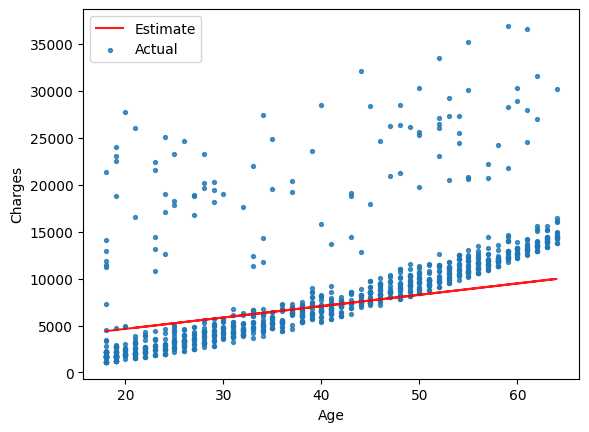

In [ ]:
try_parameters(non_smoker_df, w=121, b=2222)

- Лінія майже всюди проходить нижче основної 'лінї' точок
- нахил `w` занизький та модель недооцінює витрати для старших

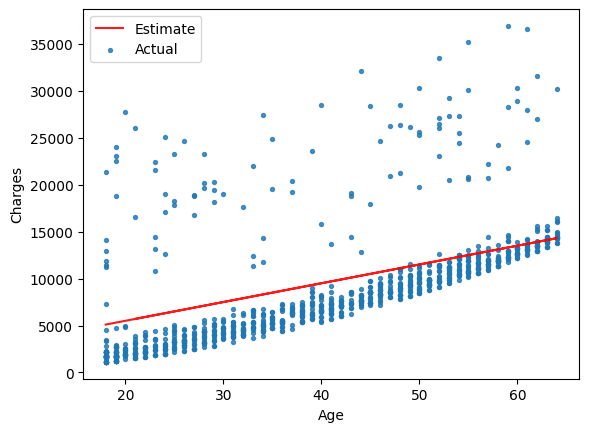

In [ ]:
try_parameters(non_smoker_df, w=200, b=1500)

- Лінія краще лягає по тренду
- Але на малих віках (18–25) вона виглядає трохи завищеною

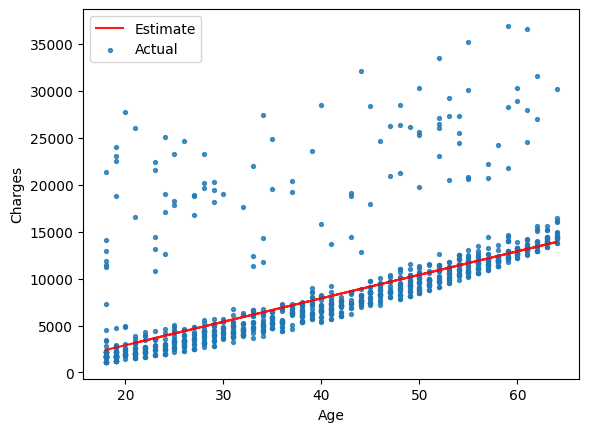

In [ ]:
try_parameters(non_smoker_df, w=250, b=-2100)

- Лінія добре проходить через основну масу некурців майже по всьому діапазону віку
- На діапозону віку 18–25 вона не завищує так сильно, як варіант w=200, b=1500
- На діапозону віку 5–65 вона теж тримається близько до центральної тенденції точок

# Завдання 6

**Завдання 6**: Напишіть фукнцію для обчислення root mean squared error згідно з формулою цієї метрики точності моделі з використанням `numpy`.

Обчисліть RMSE для тих пар пареметрів, які Ви спробували в завданні 5.

Яке найнижче значення втрат ви зможете досягти? Чи можете ви придумати загальну стратегію для знаходження кращих значень $w$ та $b$ методом проб та помилок?

In [ ]:
def rmse(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    return np.sqrt(np.mean((y_true - y_pred) ** 2))

In [ ]:
params = [[121, 2222], [200, 1500], [250, -2100]]

In [ ]:
def evaluate_params(df, w, b):
    y_true = df['charges'].values
    y_pred = estimate_charges(df['age'].values, w, b)
    return rmse(y_true, y_pred)

In [ ]:
for w, b in params:
    score = evaluate_params(non_smoker_df, w, b)
    print(f'w={w}, b={b}:')
    print(f'- RMSE: {score:.2f}\n')

w=121, b=2222:
- RMSE: 5298.12

w=200, b=1500:
- RMSE: 4850.15

w=250, b=-2100:
- RMSE: 4719.23



Найменше значення втрат серед перевірених параметрів досягнуто при `w = 250` та `b = -2100`: значення RMSE поступово зменшується, що свідчить про покращення параметрів. Але найкраща з перевірених лінійних моделей має помітну похибку, оскільки параметри були вибрани за допомогою метода проб і помилок та реальні медичні витрати залежать не лише від віку, а й від інших факторів, як BMI, регіону тощо

Стратегія пошуку кращих значень `w` та `b` методом проб і помилок:
1. Змінюємо 'w', щоб лінія приблизно відповідала загальному напрямку зростання даних
2. Змінюємо 'b', щоб лінія проходила ближче до середини основної маси точок
3. Пробуємо кілька різних значень 'w' та 'b' і порівнюємо помилки
4. Обираємо ті параметри, для яких значення RMSE найменше

Перший та другий шаг має ітеративний характер: параметри підбираються ітеративно шляхом послідовного коригування w та b